# Salinity change
Trying to determine if salinity is changing primarily due to volume fluxes or salt fluxes. 

In [38]:
import glob
import dask.distributed as dsk
import matplotlib.pyplot as plt
import xarray as xr
import cf_xarray as cfxr
import numpy as np
import xesmf as xe
from matplotlib.colors import to_rgba

import cmocean as cm
import cartopy.crs as ccrs

import cartopy.feature as cft
import matplotlib.path as mpath

import gsw

import warnings # ignore these warnings
warnings.filterwarnings("ignore", category = FutureWarning)
warnings.filterwarnings("ignore", category = UserWarning)
warnings.filterwarnings("ignore", category = RuntimeWarning)

In [39]:
lat_slice = slice(-79,-59)

# Importing data
paths_C = np.sort(glob.glob('/scratch/x77/kc5856/access-om2/archive/01deg_jra55v13_ryf9091_21mbath_daily-fc7aefa1/output000/ocean/ocean_daily.nc'))
paths_M = np.sort(glob.glob('/scratch/x77/kc5856/access-om2/archive/access-ssp126-sofia_daily-expt-3deaf0e1/output000/ocean/ocean_daily.nc'))

In [40]:
# Time variant variables
def preprocess(ds):
    ds = ds[['dzt','salt']].sel(yt_ocean=lat_slice)
    return ds

data_C = xr.open_mfdataset(paths_C, preprocess = preprocess, chunks = 'auto')
data_M = xr.open_mfdataset(paths_M, preprocess = preprocess, chunks = 'auto')


In [41]:
salinity_C = data_C.salt
salinity_M = data_M.salt

dzt_C = data_C.dzt
dzt_M = data_M.dzt

p_C = gsw.p_from_z(-data_C['st_ocean'], data_C['yt_ocean'])
p_M = gsw.p_from_z(-data_M['st_ocean'], data_M['yt_ocean'])

SA_M = gsw.SA_from_SP(salinity_M, p_M, data_M['xt_ocean'], data_M['yt_ocean']) # testing with p_C
SA_C = gsw.SA_from_SP(salinity_C, p_C, data_C['xt_ocean'], data_C['yt_ocean'])

rho_0 = 1035

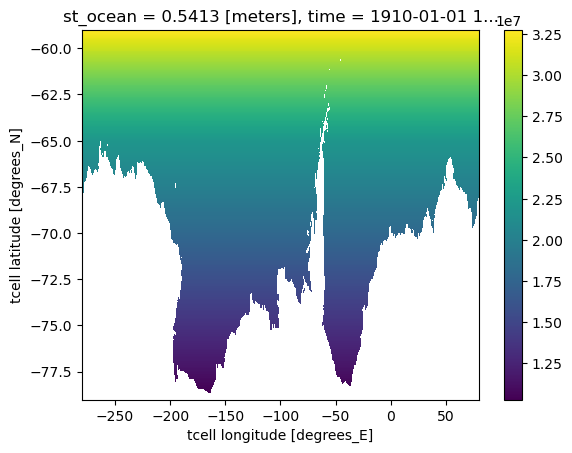

In [42]:
# Loading area
area = xr.open_dataset('/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_21mbath/output012/ocean/ocean_grid.nc')['area_t']
var = salinity_C.isel(time=0,st_ocean=0)
area_corr = area*(var*0 +1)
area_corr.plot()

In [43]:
# Shelf mask

def shelf_mask_isobath(var, model_dict):

    paths = {
             "mom5": "/g/data/ik11/grids/Antarctic_slope_contour_1000m.npz",
             "mom6_01": "/g/data/ik11/grids/Antarctic_slope_contour_1000m_MOM6_01deg.nc",
            "mom6_005": "/g/data/ik11/grids/Antarctic_slope_contour_1000m_MOM6_005deg.nc"
             }

    var = var.cf.sel({'latitude': slice(-90, -59)})

    if paths[model_dict][-3:] == '.nc':
        shelf_mask = xr.open_dataset(paths[model_dict])['contour_masked_above']
    else:
        contour_file = np.load(paths[model_dict])
        shelf_mask = xr.DataArray(contour_file['contour_masked_above'],
                                  coords = var.coords, 
                                  dims = var.dims,
                                  name = 'contour_masked_above')
    
    shelf_mask = xr.where(shelf_mask == 0, 1, 0)
    masked_var = var * shelf_mask
    
    return masked_var, shelf_mask

In [44]:
depth = xr.open_dataset('/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_21mbath/output012/ocean/ocean_grid.nc')['ht']
land_mask = (0 * depth).fillna(1)
land = xr.where(np.isnan(depth.rename('land_1')), 1, np.nan)
depth_shelf, shelf_mask = shelf_mask_isobath(depth, 'mom5')

In [45]:
vol_C = dzt_C * area_corr
vol_M = dzt_M * area_corr

total_vol_C = vol_C.where(shelf_mask ==1).sum(['xt_ocean', 'yt_ocean', 'st_ocean']) 
total_vol_M = vol_M.where(shelf_mask ==1).sum(['xt_ocean', 'yt_ocean', 'st_ocean']) 

In [46]:
# g/kg * m3 * kg/m3 gives grams of salt on the shelf
a_shelf_C = ((SA_C * vol_C).where(shelf_mask==1) * rho_0).sum(['xt_ocean', 'yt_ocean', 'st_ocean']) 
a_shelf_M = ((SA_M * vol_M).where(shelf_mask==1) * rho_0).sum(['xt_ocean', 'yt_ocean', 'st_ocean'])

In [47]:
salinity_diff = a_shelf_M/total_vol_M - a_shelf_C/total_vol_C

salinity_diff_V = a_shelf_C/total_vol_M - a_shelf_C/total_vol_C

salinity_diff_S = a_shelf_M/total_vol_C - a_shelf_C/total_vol_C

In [48]:
salinity_diff = salinity_diff.load()
salinity_diff_V = salinity_diff_V.load()
salinity_diff_S = salinity_diff_S.load()

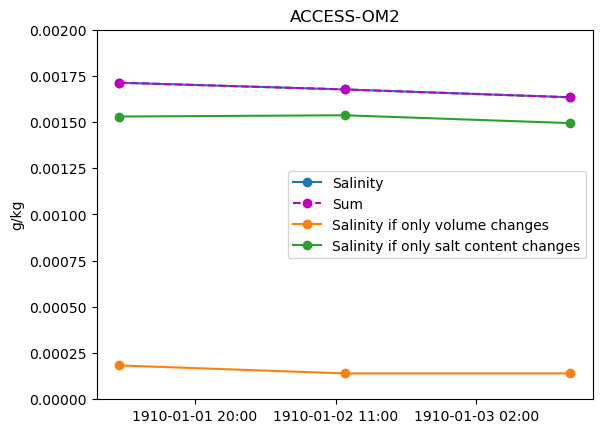

In [70]:
(salinity_diff/rho_0).plot(label='Salinity', marker='o')
((salinity_diff_S+salinity_diff_V)/rho_0).plot(c='m', linestyle='--', label='Sum', marker='o')
(salinity_diff_V/rho_0).plot(label='Salinity if only volume changes', marker='o')
(salinity_diff_S/rho_0).plot(label='Salinity if only salt content changes', marker='o')
plt.legend()
plt.ylim(0,0.002)
plt.xlabel(''); plt.ylabel('g/kg'); plt.title('ACCESS-OM2');

Checking against typical depth-integrated salinity method.

In [71]:
# Depth-integrated absolute salinity
salt_int_C = (dzt_C * SA_C).sum(['st_ocean']) / dzt_C.sum(['st_ocean'])
salt_int_M = (dzt_M * SA_M).sum(['st_ocean']) / dzt_M.sum(['st_ocean'])

In [72]:
salt_shelf_C = salt_int_C.where(shelf_mask == 1)
salt_shelf_M = salt_int_M.where(shelf_mask == 1)

In [73]:
# Spatial average
salt_time_C = (area_corr * salt_shelf_C).sum(['xt_ocean', 'yt_ocean']) / area_corr.sum(['xt_ocean', 'yt_ocean'])
salt_time_M = (area_corr * salt_shelf_M).sum(['xt_ocean', 'yt_ocean']) / area_corr.sum(['xt_ocean', 'yt_ocean'])

In [74]:
salt_time_C = salt_time_C.load()
salt_time_M = salt_time_M.load()

In [75]:
salt_time_anom = salt_time_M - salt_time_C
salt_time_anom = salt_time_anom.load()

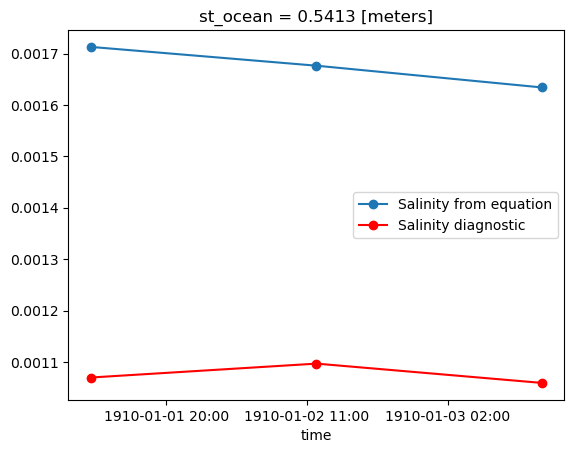

In [76]:
(salinity_diff/rho_0).plot(label='Salinity from equation', marker='o')
salt_time_anom.plot(label='Salinity diagnostic', marker='o', color='red')

plt.legend()

Trying to replicate total salinity line in first plot from regular salinity variables. It looks quite different?

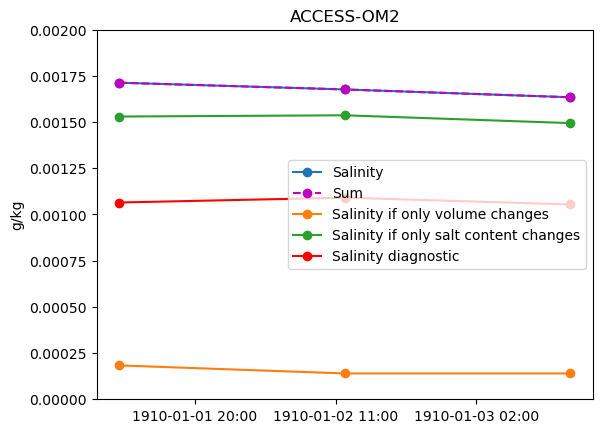

In [69]:
(salinity_diff/rho_0).plot(label='Salinity', marker='o')
((salinity_diff_S+salinity_diff_V)/rho_0).plot(c='m', linestyle='--', label='Sum', marker='o')
(salinity_diff_V/rho_0).plot(label='Salinity if only volume changes', marker='o')
(salinity_diff_S/rho_0).plot(label='Salinity if only salt content changes', marker='o')
salt_time_anom.plot(label='Salinity diagnostic', marker='o', color='red')

plt.legend(loc='center right')
plt.ylim(0,0.002)
plt.xlabel(''); plt.ylabel('g/kg'); plt.title('ACCESS-OM2');

In [77]:
salt_time_M.values

array([4.44381754, 4.44354111, 4.44324859])

In [78]:
salt_time_C.values

array([4.44274794, 4.44244449, 4.44218954])

In [79]:
salt_time_anom.values

array([0.0010696 , 0.00109662, 0.00105905])